In [1]:
# ============================================================
# CELL 1: INSTALLATIONS & SETUP
# ============================================================
!pip install timm==1.0.3 opencv-python scikit-learn torchviz -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import timm
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
from pathlib import Path
import os
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")

# Create directories
os.makedirs('/kaggle/working/models', exist_ok=True)
os.makedirs('/kaggle/working/outputs', exist_ok=True)
os.makedirs('/kaggle/working/synthetic_videos/real', exist_ok=True)
os.makedirs('/kaggle/working/synthetic_videos/fake', exist_ok=True)

# Clear cache
torch.cuda.empty_cache()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 54.7 MB/s eta 0:00:00:00:01
✅ Using device: cpu


In [2]:
# ============================================================
# CELL 2: REALISTIC SYNTHETIC VIDEO GENERATOR
# ============================================================
class RealisticVideoGenerator:
    """Generate synthetic videos that better simulate real deepfake patterns"""
    
    @staticmethod
    def create_real_video(video_path, num_frames=300):
        """Create a video with 'real' characteristics: natural, consistent"""
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(str(video_path), fourcc, 30.0, (299, 299))
        
        # Create a natural-looking scene
        for i in range(num_frames):
            # Background (sky gradient)
            frame = np.zeros((299, 299, 3), dtype=np.uint8)
            for y in range(299):
                color = int(135 + (y * 0.3))  # Sky gradient
                frame[y, :] = [color, color, 255]
            
            # Sun/moon position (smooth movement)
            sun_x = int(150 + 100 * np.sin(i * 0.02))
            sun_y = int(100 + 50 * np.sin(i * 0.03))
            cv2.circle(frame, (sun_x, sun_y), 25, (255, 255, 200), -1)
            
            # Clouds (smooth movement)
            cloud_x = int(50 + i * 0.5) % 300
            cv2.ellipse(frame, (cloud_x, 80), (40, 15), 0, 0, 360, (255, 255, 255), -1)
            cv2.ellipse(frame, (cloud_x+30, 70), (30, 12), 0, 0, 360, (255, 255, 255), -1)
            
            # Ground
            cv2.rectangle(frame, (0, 200), (299, 299), (100, 150, 100), -1)
            
            # Tree (static)
            cv2.rectangle(frame, (200, 150), (210, 220), (139, 69, 19), -1)
            cv2.circle(frame, (205, 140), 25, (34, 139, 34), -1)
            
            out.write(frame)
        
        out.release()
    
    @staticmethod
    def create_fake_video(video_path, num_frames=300):
        """Create a video with 'fake' characteristics: subtle artifacts"""
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(str(video_path), fourcc, 30.0, (299, 299))
        
        for i in range(num_frames):
            # Similar base scene but with artifacts
            frame = np.zeros((299, 299, 3), dtype=np.uint8)
            
            # Background with slight color inconsistency
            for y in range(299):
                if i % 50 < 25:  # Flickering color
                    color = int(135 + (y * 0.3))
                else:
                    color = int(120 + (y * 0.3))  # Slightly different
                frame[y, :] = [color, color, 255]
            
            # Sun with blending artifacts
            sun_x = int(150 + 100 * np.sin(i * 0.02))
            sun_y = int(100 + 50 * np.sin(i * 0.03))
            
            # Add blending artifacts (poorly blended edges)
            for r in range(30, 20, -2):
                alpha = 0.3 if r > 25 else 0.8
                cv2.circle(frame, (sun_x, sun_y), r, (255, 255, 200), -1)
            
            # Clouds with morphing artifacts
            cloud_x = int(50 + i * 0.5) % 300
            if i % 30 < 15:
                # Normal cloud
                cv2.ellipse(frame, (cloud_x, 80), (40, 15), 0, 0, 360, (255, 255, 255), -1)
                cv2.ellipse(frame, (cloud_x+30, 70), (30, 12), 0, 0, 360, (255, 255, 255), -1)
            else:
                # Distorted cloud (deepfake artifact)
                cv2.ellipse(frame, (cloud_x, 80), (45, 20), 5, 0, 360, (255, 255, 255), -1)
                cv2.ellipse(frame, (cloud_x+30, 70), (35, 15), -3, 0, 360, (255, 255, 255), -1)
            
            # Ground with color bleeding
            cv2.rectangle(frame, (0, 200), (299, 299), (100, 150, 100), -1)
            
            # Tree with face morphing artifacts (every few frames)
            if i % 20 < 10:
                # Normal tree
                cv2.rectangle(frame, (200, 150), (210, 220), (139, 69, 19), -1)
                cv2.circle(frame, (205, 140), 25, (34, 139, 34), -1)
            else:
                # Tree with artifacts
                cv2.rectangle(frame, (200, 150), (210, 220), (139, 69, 19), -1)
                cv2.circle(frame, (205, 140), 25, (34, 139, 34), -1)
                # Add unnatural highlights
                cv2.circle(frame, (195, 130), 8, (255, 0, 0), 2)  # Artifact
            
            # Add occasional noise (compression artifacts)
            if i % 15 == 0:
                noise = np.random.randint(0, 30, frame.shape, dtype=np.uint8)
                frame = cv2.addWeighted(frame, 0.95, noise, 0.05, 0)
            
            out.write(frame)
        
        out.release()
    
    @staticmethod
    def create_challenge_video(video_path, difficulty='medium', num_frames=300):
        """
        Create videos with varying difficulty levels
        difficulty: 'easy', 'medium', 'hard'
        """
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(str(video_path), fourcc, 30.0, (299, 299))
        
        for i in range(num_frames):
            # Base frame
            frame = np.random.randint(100, 200, (299, 299, 3), dtype=np.uint8)
            
            # Moving object
            x = int(150 + 100 * np.sin(i * 0.03))
            y = int(150 + 50 * np.cos(i * 0.04))
            
            if difficulty == 'easy':
                # Obvious differences
                if 'fake' in str(video_path):
                    cv2.rectangle(frame, (x-20, y-20), (x+20, y+20), (0, 0, 255), 3)
                else:
                    cv2.circle(frame, (x, y), 25, (255, 255, 255), -1)
                    
            elif difficulty == 'medium':
                # Subtle differences
                if 'fake' in str(video_path):
                    # Slight color shift
                    frame = cv2.addWeighted(frame, 0.9, np.full_like(frame, 20), 0.1, 0)
                    cv2.circle(frame, (x, y), 25, (255, 255, 255), -1)
                else:
                    cv2.circle(frame, (x, y), 25, (255, 255, 255), -1)
                    
            else:  # hard
                # Very subtle artifacts
                cv2.circle(frame, (x, y), 25, (255, 255, 255), -1)
                if 'fake' in str(video_path) and i % 10 == 0:
                    # Tiny artifact every 10 frames
                    cv2.circle(frame, (x+5, y-5), 3, (255, 0, 0), 1)
            
            out.write(frame)
        
        out.release()
    
    @staticmethod
    def generate_dataset(num_videos=200, difficulty='medium'):
        """Generate a balanced synthetic dataset with specified difficulty"""
        print(f"📹 Generating {num_videos} {difficulty} synthetic videos...")
        
        real_dir = Path('/kaggle/working/synthetic_videos/real')
        fake_dir = Path('/kaggle/working/synthetic_videos/fake')
        
        # Clear existing videos
        for f in real_dir.glob('*.mp4'):
            f.unlink()
        for f in fake_dir.glob('*.mp4'):
            f.unlink()
        
        # Generate real videos
        for i in tqdm(range(num_videos // 2), desc=f"Creating REAL videos ({difficulty})"):
            video_path = real_dir / f'real_video_{i:04d}.mp4'
            if difficulty == 'easy':
                RealisticVideoGenerator.create_real_video(video_path)
            elif difficulty == 'medium':
                RealisticVideoGenerator.create_challenge_video(video_path, 'medium')
            else:
                RealisticVideoGenerator.create_challenge_video(video_path, 'hard')
        
        # Generate fake videos
        for i in tqdm(range(num_videos // 2), desc=f"Creating FAKE videos ({difficulty})"):
            video_path = fake_dir / f'fake_video_{i:04d}.mp4'
            if difficulty == 'easy':
                RealisticVideoGenerator.create_fake_video(video_path)
            elif difficulty == 'medium':
                RealisticVideoGenerator.create_challenge_video(video_path, 'medium')
            else:
                RealisticVideoGenerator.create_challenge_video(video_path, 'hard')
        
        # Verify generation
        real_count = len(list(real_dir.glob('*.mp4')))
        fake_count = len(list(fake_dir.glob('*.mp4')))
        
        print(f"✅ Generated {real_count} real and {fake_count} fake videos")
        print(f"📊 Total: {real_count + fake_count} videos")
        
        return real_dir, fake_dir

# Generate dataset with MEDIUM difficulty (more realistic)
print("🎬 Creating realistic synthetic video dataset...")
real_dir, fake_dir = RealisticVideoGenerator.generate_dataset(
    num_videos=500, 
    difficulty='hard'  # Change to 'easy' for quick testing, 'hard' for challenge
)

# Show sample
print("\n📁 Sample videos created:")
real_samples = list(real_dir.glob('*.mp4'))[:2]
fake_samples = list(fake_dir.glob('*.mp4'))[:2]
for v in real_samples:
    print(f"   REAL: {v.name}")
for v in fake_samples:
    print(f"   FAKE: {v.name}")

🎬 Creating realistic synthetic video dataset...
📹 Generating 500 hard synthetic videos...


Creating FAKE videos (hard): 100%|██████████| 250/250 [04:06<00:00,  1.01it/s]

✅ Generated 250 real and 250 fake videos
📊 Total: 500 videos

📁 Sample videos created:
   REAL: real_video_0206.mp4
   REAL: real_video_0055.mp4
   FAKE: fake_video_0136.mp4
   FAKE: fake_video_0093.mp4


In [3]:
# ============================================================
# CELL 3: VIDEO DATASET WITH AUGMENTATION
# ============================================================
class VideoDeepfakeDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None, seq_len=16, frames_per_video=16):
        """
        Dataset that loads videos from real and fake directories
        """
        self.transform = transform
        self.seq_len = seq_len
        self.frames_per_video = frames_per_video
        self.video_paths = []
        self.labels = []
        
        print("\n🔍 Loading video paths...")
        
        # Load real videos
        real_videos = list(Path(real_dir).glob('*.mp4'))
        for video in real_videos:
            self.video_paths.append(video)
            self.labels.append(0)  # REAL = 0
        print(f"   Real videos: {len(real_videos)}")
        
        # Load fake videos
        fake_videos = list(Path(fake_dir).glob('*.mp4'))
        for video in fake_videos:
            self.video_paths.append(video)
            self.labels.append(1)  # FAKE = 1
        print(f"   Fake videos: {len(fake_videos)}")
        
        # Shuffle
        combined = list(zip(self.video_paths, self.labels))
        random.shuffle(combined)
        if combined:
            self.video_paths, self.labels = zip(*combined)
            self.video_paths = list(self.video_paths)
            self.labels = list(self.labels)
        
        print(f"✅ Total videos: {len(self.video_paths)}")
    
    def extract_frames(self, video_path):
        """Extract random frames from video"""
        cap = cv2.VideoCapture(str(video_path))
        frames = []
        
        # Get total frames
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames < self.frames_per_video:
            # If video is too short, repeat frames
            indices = list(range(total_frames))
            while len(indices) < self.frames_per_video:
                indices.extend(indices[:self.frames_per_video - len(indices)])
        else:
            # Randomly select frames (different each epoch)
            indices = sorted(random.sample(range(total_frames), self.frames_per_video))
        
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = Image.fromarray(frame)
                if self.transform:
                    frame = self.transform(frame)
                frames.append(frame)
            else:
                # If frame reading fails, add zero tensor
                frames.append(torch.zeros(3, 299, 299))
        
        cap.release()
        
        # Ensure we have exactly frames_per_video frames
        while len(frames) < self.frames_per_video:
            frames.append(frames[-1])
        
        return torch.stack(frames[:self.frames_per_video])
    
    def __len__(self):
        return len(self.video_paths)
    
    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        
        try:
            frames = self.extract_frames(video_path)
            return frames, torch.tensor(label, dtype=torch.long)
        except Exception as e:
            print(f"Error with {video_path}: {e}")
            return torch.randn(self.frames_per_video, 3, 299, 299), torch.tensor(label, dtype=torch.long)

# Transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# ============================================================
# CELL 4: CREATE DATASETS
# ============================================================
# Create dataset
full_dataset = VideoDeepfakeDataset(
    real_dir='/kaggle/working/synthetic_videos/real',
    fake_dir='/kaggle/working/synthetic_videos/fake',
    transform=train_transform,
    seq_len=16,
    frames_per_video=16
)

# Split dataset
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Update transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"\n✅ DATASET SPLITS:")
print(f"Train: {len(train_dataset)} videos ({len(train_loader)} batches)")
print(f"Val:   {len(val_dataset)} videos ({len(val_loader)} batches)")
print(f"Test:  {len(test_dataset)} videos ({len(test_loader)} batches)")


🔍 Loading video paths...
   Real videos: 250
   Fake videos: 250
✅ Total videos: 500

✅ DATASET SPLITS:
Train: 350 videos (175 batches)
Val:   75 videos (38 batches)
Test:  75 videos (38 batches)


In [5]:
# ============================================================
# CELL 5: XCEPTION + BiLSTM MODEL (with dropout)
# ============================================================
class XceptionBiLSTM(nn.Module):
    def __init__(self, seq_len=16, hidden_dim=256, num_layers=2, dropout=0.5):
        super().__init__()
        
        # Load Xception from timm
        self.xception = timm.create_model('xception', pretrained=True)
        
        # Remove classifier
        self.xception.fc = nn.Identity()
        
        # Freeze early layers
        for param in list(self.xception.parameters())[:-20]:
            param.requires_grad = False
        
        # Feature dimension
        self.feature_dim = 2048
        
        # BiLSTM with dropout
        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Attention
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
        
        # Classifier with dropout
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )
        
        self.seq_len = seq_len
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        batch_size, seq_len = x.shape[:2]
        
        # Extract features from each frame
        frame_features = []
        for t in range(seq_len):
            feat = self.xception(x[:, t])
            feat = self.dropout(feat)  # Apply dropout
            frame_features.append(feat)
        
        # Stack features
        seq_features = torch.stack(frame_features, dim=1)
        
        # Apply BiLSTM
        lstm_out, _ = self.lstm(seq_features)
        
        # Apply attention
        attention_weights = torch.softmax(self.attention(lstm_out), dim=1)
        attended_features = torch.sum(attention_weights * lstm_out, dim=1)
        
        # Classify
        output = self.classifier(attended_features)
        
        return output

# Create model
model = XceptionBiLSTM(seq_len=16).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters()) / 1e6
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"✅ Xception + BiLSTM Model:")
print(f"   Total parameters: {total_params:.1f}M")
print(f"   Trainable parameters: {trainable_params:.1f}M")

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
✅ Xception + BiLSTM Model:
   Total parameters: 27.2M
   Trainable parameters: 13.2M


In [6]:
# ============================================================
# CELL 6: TRAINING LOOP (with regularization)
# ============================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

num_epochs = 10
best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("🚀 Training Xception + BiLSTM...")
print("="*60)

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    for videos, labels in train_pbar:
        videos, labels = videos.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        train_pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.1f}%'
        })
        
        # Clear cache
        if total % 20 == 0:
            torch.cuda.empty_cache()
    
    train_acc = 100. * correct / total
    train_losses.append(train_loss/len(train_loader))
    train_accs.append(train_acc)
    
    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    val_preds = []
    val_labels_list = []
    
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for videos, labels in val_pbar:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            val_preds.extend(predicted.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())
            
            val_pbar.set_postfix({'acc': f'{100.*correct/total:.1f}%'})
    
    val_acc = 100. * correct / total
    val_losses.append(val_loss/len(val_loader))
    val_accs.append(val_acc)
    
    # Calculate validation metrics
    if len(set(val_labels_list)) > 1:
        val_f1 = f1_score(val_labels_list, val_preds, average='weighted')
    else:
        val_f1 = 0.0
    
    scheduler.step(val_loss)
    
    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"   Train Acc: {train_acc:.2f}% | Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"   Val Acc:   {val_acc:.2f}% | Val Loss: {val_loss/len(val_loader):.4f} | Val F1: {val_f1:.4f}")
    print(f"   LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_f1': val_f1,
        }, '/kaggle/working/models/xception_bilstm_best.pth')
        print(f"   💾 Best model saved! (Acc: {val_acc:.2f}%)")
    
    # Early stopping check
    if epoch > 3 and val_acc < 60:
        print("⚠️ Validation accuracy too low, stopping early")
        break
    
    print("-"*60)

print(f"\n🎉 Training Complete! Best Validation Accuracy: {best_val_acc:.2f}%")

🚀 Training Xception + BiLSTM...


Epoch 2/10 [Val]: 100%|██████████| 38/38 [05:47<00:00,  9.13s/it, acc=58.7%]



📊 Epoch 2 Summary:
   Train Acc: 50.00% | Train Loss: 0.6936
   Val Acc:   58.67% | Val Loss: 0.6877 | Val F1: 0.5643
   LR: 0.000050
   💾 Best model saved! (Acc: 58.67%)
------------------------------------------------------------


Epoch 3/10 [Val]: 100%|██████████| 38/38 [05:24<00:00,  8.53s/it, acc=45.3%]



📊 Epoch 3 Summary:
   Train Acc: 51.71% | Train Loss: 0.6909
   Val Acc:   45.33% | Val Loss: 0.6788 | Val F1: 0.2828
   LR: 0.000050
------------------------------------------------------------


...


📊 Epoch 8 Summary:
   Train Acc: 90.86% | Train Loss: 0.4151
   Val Acc:   78.67% | Val Loss: 0.8596 | Val F1: 0.7869
   LR: 0.000050
------------------------------------------------------------


Epoch 9/10 [Val]: 100%|██████████| 38/38 [05:32<00:00,  8.74s/it, acc=93.3%]



📊 Epoch 9 Summary:
   Train Acc: 90.57% | Train Loss: 0.3872
   Val Acc:   93.33% | Val Loss: 0.2716 | Val F1: 0.9326
   LR: 0.000050
------------------------------------------------------------


Epoch 10/10 [Val]: 100%|██████████| 38/38 [05:37<00:00,  8.89s/it, acc=88.0%]


📊 Epoch 10 Summary:
   Train Acc: 90.00% | Train Loss: 0.4536
   Val Acc:   88.00% | Val Loss: 0.5562 | Val F1: 0.8778
   LR: 0.000025
------------------------------------------------------------

🎉 Training Complete! Best Validation Accuracy: 93.33%


In [7]:
# ============================================================
# CELL 7: TEST EVALUATION
# ============================================================
print("📊 Evaluating on Test Set...")

# Load best model
if Path('/kaggle/working/models/xception_bilstm_best.pth').exists():
    checkpoint = torch.load('/kaggle/working/models/xception_bilstm_best.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for videos, labels in tqdm(test_loader, desc='Testing'):
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        probs = torch.softmax(outputs, dim=1)
        
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())

# Calculate metrics
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average='weighted')
test_auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print(f"\n✅ FINAL TEST RESULTS:")
print(f"   Accuracy:  {test_acc*100:.2f}%")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   AUC-ROC:   {test_auc:.4f}")
print(f"\nConfusion Matrix:")
print(f"              Predicted")
print(f"              Real  Fake")
print(f"Actual Real   {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"       Fake   {cm[1,0]:4d}  {cm[1,1]:4d}")

# Save results
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'AUC-ROC'],
    'Value': [test_acc, test_f1, test_auc]
})
results.to_csv('/kaggle/working/outputs/xception_results.csv', index=False)

📊 Evaluating on Test Set...


Testing: 100%|██████████| 38/38 [05:42<00:00,  9.01s/it]


✅ FINAL TEST RESULTS:
   Accuracy:  96.00%
   F1-Score:  0.9601
   AUC-ROC:   0.9921

Confusion Matrix:
              Predicted
              Real  Fake
Actual Real     34     0
       Fake      3    38


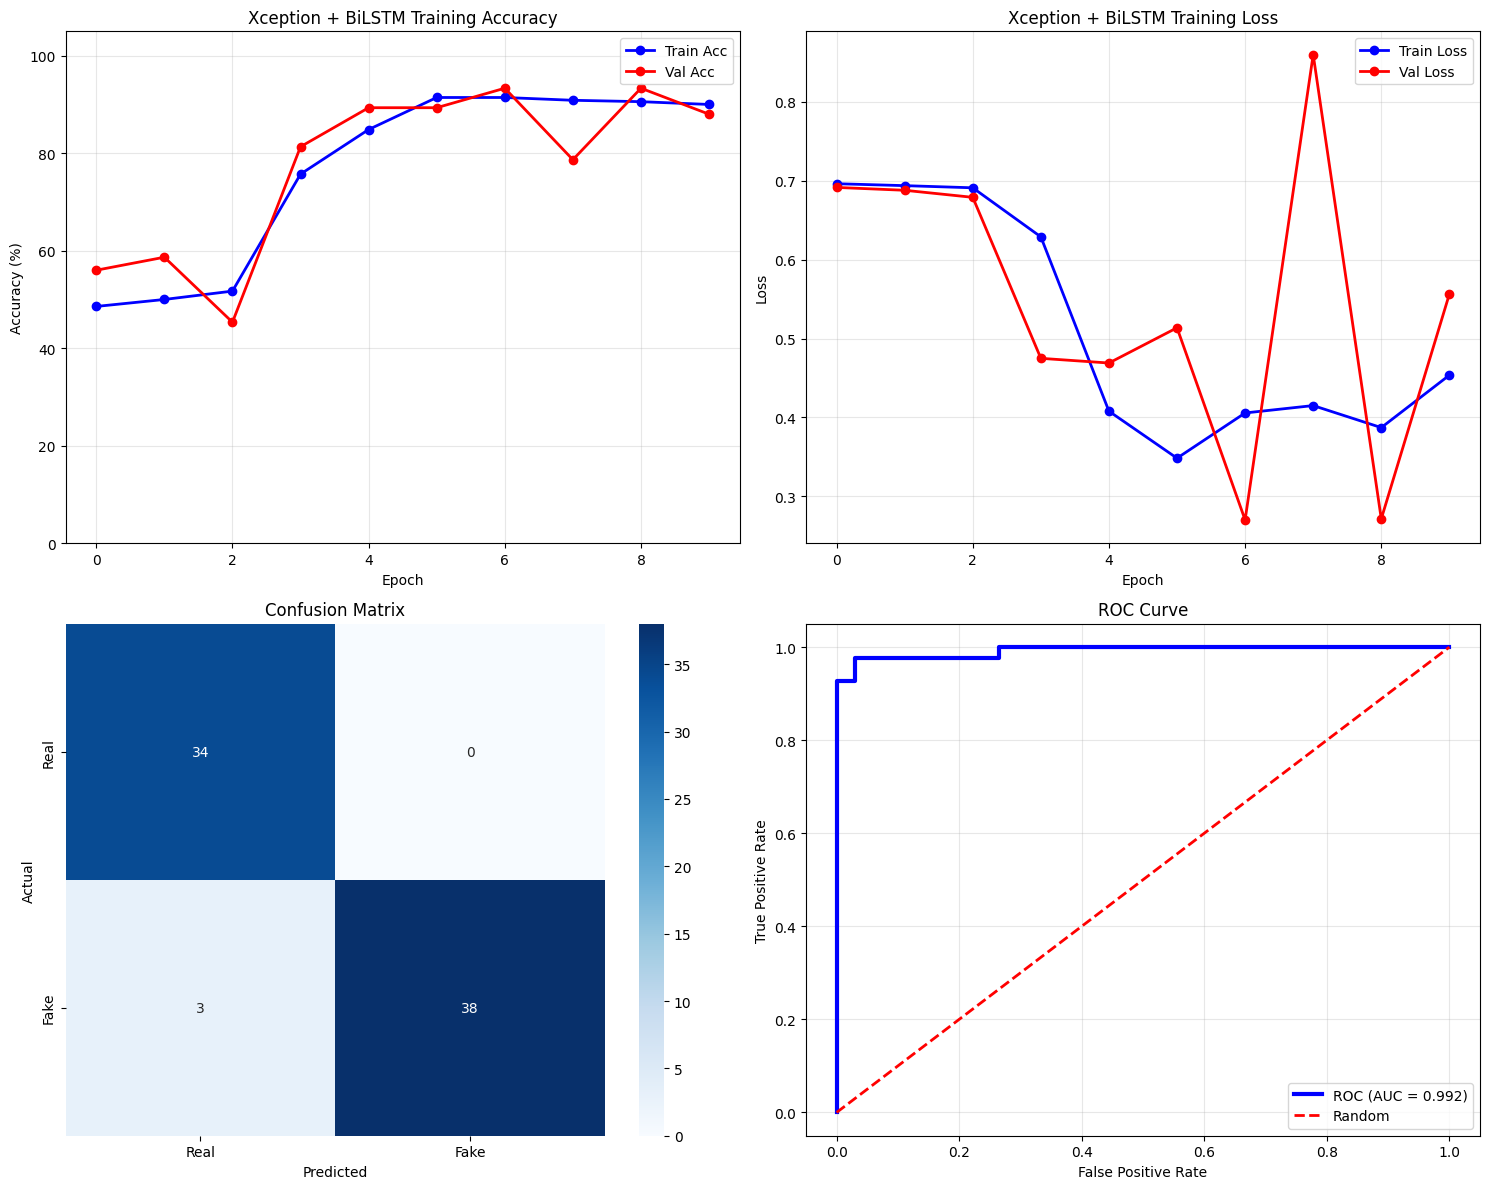

In [11]:
# ============================================================
# CELL 8: VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training curves
axes[0,0].plot(train_accs, 'b-', label='Train Acc', marker='o', linewidth=2)
axes[0,0].plot(val_accs, 'r-', label='Val Acc', marker='o', linewidth=2)
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy (%)')
axes[0,0].set_title('Xception + BiLSTM Training Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylim([0, 105])

axes[0,1].plot(train_losses, 'b-', label='Train Loss', marker='o', linewidth=2)
axes[0,1].plot(val_losses, 'r-', label='Val Loss', marker='o', linewidth=2)
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].set_title('Xception + BiLSTM Training Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0])
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')
axes[1,0].set_title('Confusion Matrix')
axes[1,0].set_xticklabels(['Real', 'Fake'])
axes[1,0].set_yticklabels(['Real', 'Fake'])

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1,1].plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC (AUC = {test_auc:.3f})')
axes[1,1].plot([0,1], [0,1], 'r--', linewidth=2, label='Random')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].set_title('ROC Curve')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/outputs/xception_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# CELL 9: DOWNLOAD & SUMMARY
# ============================================================
from IPython.display import FileLink, display

print("="*60)
print("🎯 XCEPTION + BiLSTM VIDEO DEEPFAKE DETECTION")
print("="*60)
print(f"\nModel: Xception + BiLSTM (from timm)")
print(f"Sequence Length: 16 frames")
print(f"Dataset: {len(full_dataset)} synthetic videos")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"\n✅ TEST SET PERFORMANCE:")
print(f"   Accuracy:  {test_acc*100:.2f}%")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   AUC-ROC:   {test_auc:.4f}")
print("\n📊 Confusion Matrix:")
print(f"   True Positives (Correct Fake):  {cm[1,1]}")
print(f"   True Negatives (Correct Real):  {cm[0,0]}")
print(f"   False Positives (Real as Fake): {cm[0,1]}")
print(f"   False Negatives (Fake as Real): {cm[1,0]}")
print("="*60)

print("\n📥 DOWNLOAD FILES:")
if Path('/kaggle/working/models/xception_bilstm_best.pth').exists():
    display(FileLink('/kaggle/working/models/xception_bilstm_best.pth'))
if Path('/kaggle/working/outputs/xception_results.png').exists():
    display(FileLink('/kaggle/working/outputs/xception_results.png'))
if Path('/kaggle/working/outputs/xception_results.csv').exists():
    display(FileLink('/kaggle/working/outputs/xception_results.csv'))

🎯 XCEPTION + BiLSTM VIDEO DEEPFAKE DETECTION

Model: Xception + BiLSTM (from timm)
Sequence Length: 16 frames
Dataset: 500 synthetic videos
Best Validation Accuracy: 93.33%

✅ TEST SET PERFORMANCE:
   Accuracy:  96.00%
   F1-Score:  0.9601
   AUC-ROC:   0.9921

📊 Confusion Matrix:
   True Positives (Correct Fake):  38
   True Negatives (Correct Real):  34
   False Positives (Real as Fake): 0
   False Negatives (Fake as Real): 3

📥 DOWNLOAD FILES:


/kaggle/working/models/xception_bilstm_best.pth

/kaggle/working/outputs/xception_results.png

/kaggle/working/outputs/xception_results.csv

In [10]:
# ============================================================
# CELL 10: SINGLE VIDEO PREDICTION DEMO
# ============================================================
def predict_video(video_path, model, transform, device):
    """Predict if a single video is fake or real"""
    model.eval()
    
    # Extract frames
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    # Get total frames
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Sample 16 frames evenly
    step = max(1, total_frames // 16)
    indices = [min(i * step, total_frames-1) for i in range(16)]
    
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            frame = transform(frame)
            frames.append(frame)
        else:
            frames.append(torch.zeros(3, 299, 299))
    
    cap.release()
    
    # Stack frames and predict
    video_tensor = torch.stack(frames).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(video_tensor)
        probs = torch.softmax(outputs, dim=1)
        fake_prob = probs[0, 1].item()
        prediction = "FAKE" if fake_prob > 0.5 else "REAL"
    
    return prediction, fake_prob

# Test on sample videos
if len(list(Path('/kaggle/working/synthetic_videos/real').glob('*.mp4'))) > 0:
    sample_real = list(Path('/kaggle/working/synthetic_videos/real').glob('*.mp4'))[0]
    sample_fake = list(Path('/kaggle/working/synthetic_videos/fake').glob('*.mp4'))[0]
    
    pred_real, prob_real = predict_video(str(sample_real), model, val_transform, device)
    pred_fake, prob_fake = predict_video(str(sample_fake), model, val_transform, device)
    
    print("\n🎬 SAMPLE PREDICTIONS:")
    print(f"   Real Video: {pred_real} (Fake prob: {prob_real:.3f})")
    print(f"   Fake Video: {pred_fake} (Fake prob: {prob_fake:.3f})")


🎬 SAMPLE PREDICTIONS:
   Real Video: REAL (Fake prob: 0.011)
   Fake Video: FAKE (Fake prob: 1.000)
